# 2D checkerboard in flow matching

This notebook contains a primary instantiaition of flow matching, the 2D checkerboard.

Dataset:2D checkboard
Model:MLP
Scheduler:CondOT

# Improts and init devices

In [1]:
import time
import torch

from torch import nn, Tensor

# flow_matching equivalents (local project)
from model.path.scheduler import CondOTScheduler
from model.path import AffineProbPath
from model.solver import ODESolver
from utils import ModelWrapper

# visualization
import matplotlib.pyplot as plt
from matplotlib import cm

# To avoide meshgrid warning
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='torch')

In [2]:
seed = 42
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# Dataset

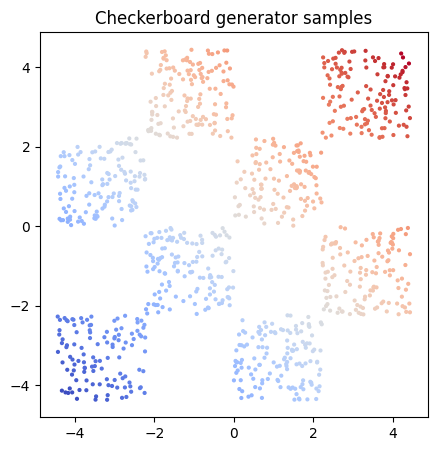

In [13]:
# Infinite generator matching the example checkerboard construction
def inf_train_gen(batch_size: int = 200, device: str = 'cpu'):
    # x1 uniform in [-2,2]
    x1 = torch.rand(batch_size, device=device) * 4 - 2
    # second coord creates checkerboard pattern
    x2_ = torch.rand(batch_size, device=device) - torch.randint(high=2, size=(batch_size,), device=device) * 2
    x2 = x2_ + (torch.floor(x1) % 2)

    data = 1.0 * torch.cat([x1[:, None], x2[:, None]], dim=1) / 0.45
    return data.float()

# quick visualization of samples from the generator
samples = inf_train_gen(batch_size=1024, device='cpu').numpy()
plt.figure(figsize=(5,5))
plt.scatter(samples[:,0], samples[:,1], s=4, c=samples[:,0]+samples[:,1], cmap='coolwarm')
plt.title('Checkerboard generator samples')
plt.show()

# Model

In [5]:
# Activation and model definitions matching the example MLP
class Swish(nn.Module):
    def forward(self, x: Tensor) -> Tensor:
        return torch.sigmoid(x) * x

class MLP(nn.Module):
    def __init__(self, input_dim: int = 2, time_dim: int = 1, hidden_dim: int = 128):
        super().__init__()
        self.input_dim = input_dim
        self.time_dim = time_dim
        self.hidden_dim = hidden_dim
        self.main = nn.Sequential(
            nn.Linear(input_dim + time_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, input_dim),
        )

    def forward(self, x: Tensor, t: Tensor) -> Tensor:
        sz = x.size()
        x = x.reshape(-1, self.input_dim)
        t = t.reshape(-1, self.time_dim).float()
        t = t.reshape(-1, 1).expand(x.shape[0], 1)
        h = torch.cat([x, t], dim=1)
        output = self.main(h)
        return output.reshape(*sz)

class WrappedModel(ModelWrapper):
    def forward(self, x: torch.Tensor, t: torch.Tensor, **extras):
        return self.model(x, t, **extras)

# instantiate model, scheduler and wrapper
vf = MLP(input_dim=2, time_dim=1, hidden_dim=128).to(device)
scheduler = CondOTScheduler()
path = AffineProbPath(scheduler=CondOTScheduler())
optim = torch.optim.Adam(vf.parameters(), lr=1e-3)
wrapper = WrappedModel(vf)

# Training

In [6]:
# training arguments
lr = 0.001
batch_size = 4096
iterations = 20001
print_every = 2000
hidden_dim = 512

# velocity field model already initialized as vf

optim = torch.optim.Adam(vf.parameters(), lr=lr)
start_time = time.time()
for i in range(iterations):
    optim.zero_grad()

    # sample data via generator
    x_1 = inf_train_gen(batch_size=batch_size, device=device)
    x_0 = torch.randn_like(x_1).to(device)

    # sample time
    t = torch.rand(x_1.shape[0], device=device)

    # sample probability path
    path_sample = path.sample(t=t, x_0=x_0, x_1=x_1)

    # flow matching l2 loss
    loss = torch.pow(vf(path_sample.x_t, path_sample.t) - path_sample.dx_t, 2).mean()

    # optimizer step
    loss.backward()
    optim.step()

    # log loss
    if (i+1) % print_every == 0:
        elapsed = time.time() - start_time
        print('| iter {:6d} | {:5.2f} ms/step | loss {:8.3f} '.format(i+1, elapsed*1000/print_every, loss.item()))
        start_time = time.time()

| iter   2000 |  2.08 ms/step | loss    3.785 
| iter   4000 |  1.90 ms/step | loss    3.771 
| iter   6000 |  1.93 ms/step | loss    3.942 
| iter   8000 |  1.93 ms/step | loss    3.654 
| iter  10000 |  1.93 ms/step | loss    3.728 
| iter  12000 |  1.94 ms/step | loss    3.714 
| iter  14000 |  1.97 ms/step | loss    3.794 
| iter  16000 |  1.94 ms/step | loss    3.833 
| iter  18000 |  1.94 ms/step | loss    3.838 
| iter  20000 |  1.84 ms/step | loss    3.831 


# Wrap the trained velocity field for the ODE solver

In [ ]:

wrapped_vf = WrappedModel(vf)

# step size for ode solver
step_size = 0.05
norm = cm.colors.Normalize(vmax=50, vmin=0)
batch_size = 50000
T = torch.linspace(0,1,10).to(device=device)
x_init = torch.randn((batch_size, 2), dtype=torch.float32, device=device)
solver = ODESolver(velocity_model=wrapped_vf)
sol = solver.sample(time_grid=T, x_init=x_init, method='midpoint', step_size=step_size, return_intermediates=True)
sol = sol.cpu().numpy()
T = T.cpu()

# Visualize the path evolution as histograms

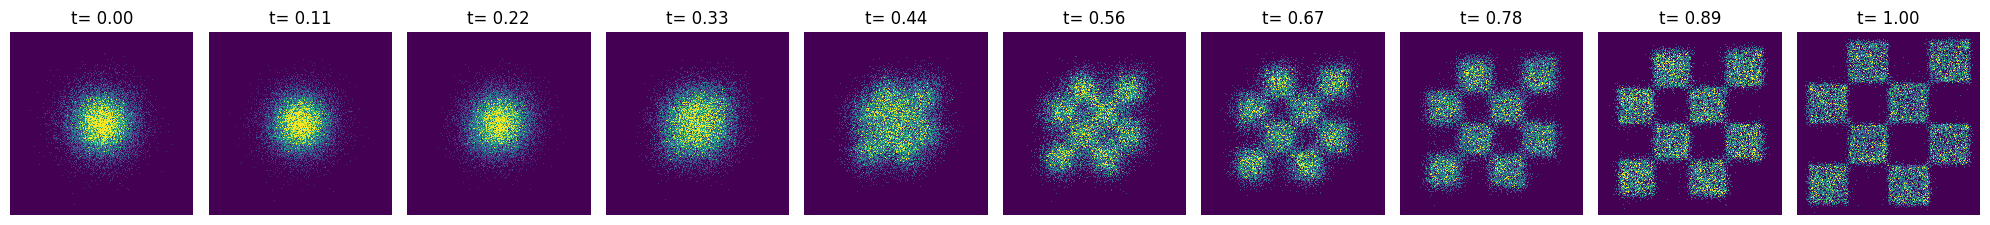

In [ ]:

fig, axs = plt.subplots(1, 10, figsize=(20,20))
for i in range(10):
    H = axs[i].hist2d(sol[i,:,0], sol[i,:,1], 300, range=((-5,5),(-5,5)))
    cmin = 0.0
    cmax = torch.quantile(torch.from_numpy(H[0]), 0.99).item()
    norm = cm.colors.Normalize(vmax=cmax, vmin=cmin)
    _ = axs[i].hist2d(sol[i,:,0], sol[i,:,1], 300, range=((-5,5),(-5,5)), norm=norm)
    axs[i].set_aspect('equal')
    axs[i].axis('off')
    axs[i].set_title('t= %.2f' % (T[i]))
plt.tight_layout()
plt.show()

# Compute model likelihood using the solver's compute_likelihood method

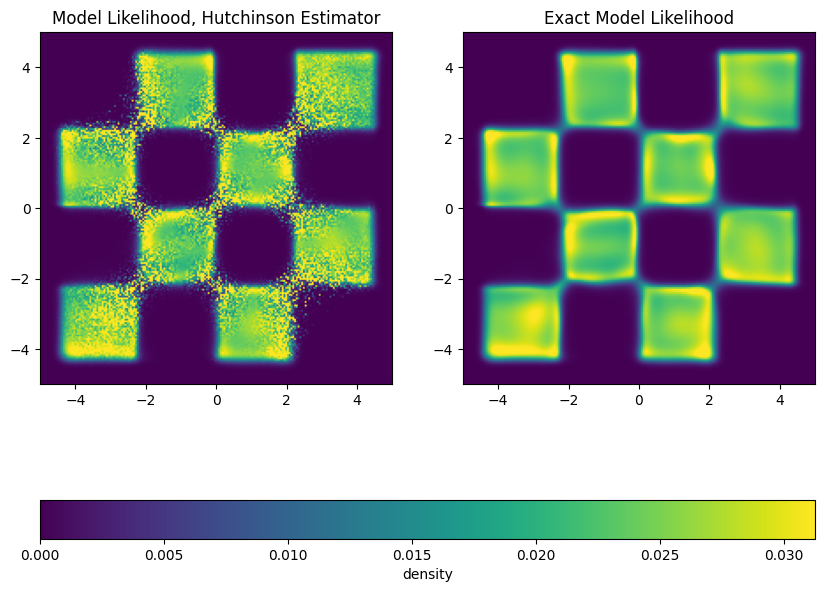

In [ ]:

from torch.distributions import Independent, Normal
# source distribution is an isotropic gaussian
gaussian_log_density = Independent(Normal(torch.zeros(2, device=device), torch.ones(2, device=device)), 1).log_prob
# compute log likelihood with unbiased hutchinson estimator, average over num_acc
num_acc = 5
log_p_acc = 0
grid_size = 200
x_1 = torch.meshgrid(torch.linspace(-5, 5, grid_size), torch.linspace(-5, 5, grid_size))
x_1 = torch.stack([x_1[0].flatten(), x_1[1].flatten()], dim=1).to(device)
for i in range(num_acc):
    _, log_p = solver.compute_likelihood(x_1=x_1, method='midpoint', step_size=step_size, exact_divergence=False, log_p0=gaussian_log_density)
    log_p_acc += log_p
log_p_acc /= num_acc
_, exact_log_p = solver.compute_likelihood(x_1=x_1, method='midpoint', step_size=step_size, exact_divergence=True, log_p0=gaussian_log_density)
likelihood = torch.exp(log_p_acc).cpu().reshape(grid_size, grid_size).detach().numpy()
exact_likelihood = torch.exp(exact_log_p).cpu().reshape(grid_size, grid_size).detach().numpy()
fig, axs = plt.subplots(1, 2, figsize=(10,10))
cmin = 0.0
cmax = 1/32
norm = cm.colors.Normalize(vmax=cmax, vmin=cmin)
axs[0].imshow(likelihood, extent=(-5,5,-5,5), origin='lower', cmap='viridis', norm=norm)
axs[0].set_title('Model Likelihood, Hutchinson Estimator')
axs[1].imshow(exact_likelihood, extent=(-5,5,-5,5), origin='lower', cmap='viridis', norm=norm)
axs[1].set_title('Exact Model Likelihood')
fig.colorbar(cm.ScalarMappable(norm=norm, cmap='viridis'), ax=axs, orientation='horizontal', label='density')
plt.show()